In [1]:
import os
path_root = os.getcwd()
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap
from matplotlib.ticker import MultipleLocator
import seaborn as sns
from datetime import datetime, timedelta
from tqdm import tqdm_notebook
os.environ['USE_PYGEOS'] = '0'
import pickle
import yaml
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split, KFold
import warnings
warnings.filterwarnings("ignore")

os.chdir('../py/')
# from compute import *
# #from compute import hits2skill, define_area_ranges, hits_by_area, summarize_by_area
# from convert import dict2da
# from optimize import find_best_criterion, find_best_criteria, find_best_criteria_cv
# from plot.results import * #lineplot_hits, lineplot_skill, plot_skill_training, plot_hits_by_variable, plot_skill_by_variable, plot_skill_by_probability
from plot.maps import create_cmap, map_stations, map_hits, map_skill, map_events
os.chdir(path_root)

In [2]:
# Set the default text font size
plt.rc('font', size=15)
# Set the axes title font size
plt.rc('axes', titlesize=16)
# Set the axes labels font size
plt.rc('axes', labelsize=15)
# Set the font size for x tick labels
plt.rc('xtick', labelsize=13)
# Set the font size for y tick labels
plt.rc('ytick', labelsize=13)
# Set the legend font size
plt.rc('legend', fontsize=13)
# Set the font size of the figure title
plt.rc('figure', titlesize=17)

## 1 Configuration

In [3]:
# with open("../conf/config_NWP_leadtime_ranges.yml", "r", encoding='utf8') as ymlfile:
with open("../conf/config_NWP_daily.yml", "r", encoding='utf8') as ymlfile:
    cfg = yaml.load(ymlfile, Loader=yaml.FullLoader)

### 1.1 Reporting points

In [4]:
# area threshold
area_threshold = cfg.get('reporting_points', {}).get('area', 500)

# reporting points
path_stations = cfg.get('reporting_points', {}).get('output', '../results/reporting_points/')
file_stations = f'{path_stations}reporting_points_over_{area_threshold}km2.parquet'

# catchments
catchments = cfg.get('reporting_points', {}).get('catchments', None)

# minimum performance required from the reporting points
min_kge = cfg.get('reporting_points', {}).get('KGE', None)

### 1.2 Hits

In [5]:
# lead time ranges
leadtime = cfg.get('hits', {}).get('leadtime', None)

# parameters of the rolling window used to compute hits
window = cfg.get('hits', {}).get('window', 1)

# dissagregate the analysis by seasons?
seasonality = cfg.get('hits', {}).get('seasonality', False)

# path that contains the NetCDFs with hit, misses and false alarms pro
path_in = cfg.get('hits', {}).get('output', '../results/hits/')
if leadtime is None:
    folder = 'all_leadtimes'
elif len(leadtime) == 10:
    folder = 'daily'
elif len(leadtime) == 20:
    folder = '12h'
else:
    folder = '_'.join([str(lt + 12) for lt in leadtime])
path_in = f'{path_in}NWP/{folder}/window_{window}/'

### 1.3 Skill

In [6]:
# current operationa criteria
current_criteria = cfg.get('skill', {}).get('current_criteria', None)

# fixed notification criteria
min_leadtime = cfg.get('skill', {}).get('leadtime', 60)
min_area = cfg.get('skill', {}).get('area', 2000)

# coefficient of the fbeta-score
beta = cfg.get('skill', {}).get('beta', 1) #[.8, 1, 1.2]
metric = f'f{beta}'

# optimization parameters
kfold = cfg.get('skill', {}).get('optimization', {}).get('kfold', None)
train_size = cfg.get('skill', {}).get('optimization', {}).get('train_size', .8)
stratify = cfg.get('skill', {}).get('optimization', {}).get('stratify', False)
tolerance = cfg.get('skill', {}).get('optimization', {}).get('tolerance', 1e-2)
min_spread = cfg.get('skill', {}).get('optimization', {}).get('minimize_spread', True)

# path where results will be saved
path_out_root = cfg.get('skill', {}).get('output', f'../results/skill/')
path_out = f'{path_out_root}NWP/{folder}/'
if min_kge is not None:
    path_out = f'{path_out}window_{window}/kge_{min_kge}/'
else:
    path_out = f'{path_out}window_{window}/no_kge/'
for path in [path_out_root, path_out, f'{path_out}{metric}/']:
    if os.path.exists(path) is False:
        os.makedirs(path)

## 2 Data
### 2.1 Reporting points

In [7]:
# load table of fixed reporting points
stations = pd.read_parquet(file_stations)
stations[['X', 'Y', 'area']] = stations[['X', 'Y', 'area']].astype(int)

# select stations that belong to the selected catchments
if catchments is not None:
    if isinstance(catchments, list) is False:
        catchments = [catchments]
    stations = stations.loc[stations.catchment.isin(catchments),:]

# remove points with a performance (KGE) lower than the established threshold
if min_kge is not None:
    mask_kge = ~(stations.KGE <= min_kge)
    stations = stations.loc[mask_kge]
else:
    # remove station with erroneous behaviour
    stations = stations.loc[~(stations.n_events_obs >= 6)]

In [ ]:
import os
os.environ['USE_PYGEOS'] = '0'
import pandas as pd
import geopandas as gpd

In [10]:
from pathlib import Path

In [11]:
path = Path('../results/skill/2020_2023/')

In [12]:
path_NWP = path / 'NWP/12_60_144_180/window_1/kge_0.5/f0.8/'
path_COMB = path / 'combination/12_60_144_180/window_1/kge_0.5/f0.8/'

In [13]:
points_NWP = pd.read_parquet(path_NWP / 'reporting_points_over_500km2.parquet')

In [14]:
points_COMB = pd.read_parquet(path_COMB / 'reporting_points_over_500km2.parquet')

In [22]:
(points_COMB[metric] - points_NWP[metric]).value_counts()

 0.000000    908
 1.000000     25
 0.280702      9
 0.719298      5
 0.561644      5
-0.378788      5
-0.280702      3
-0.233645      3
 0.170068      3
 0.378788      3
 0.164414      2
 0.054002      2
-0.549451      2
-0.085034      1
-0.050868      1
 0.132275      1
-0.187215      1
 0.115108      1
 0.159413      1
 0.071535      1
-1.000000      1
-0.244062      1
 0.064685      1
 0.189394      1
 0.248299      1
-0.081788      1
 0.089771      1
-0.062668      1
 0.219298      1
-0.275091      1
-0.219298      1
-0.005654      1
-0.170663      1
 0.621212      1
-0.132275      1
 0.120098      1
-0.110215      1
 0.233645      1
 0.275091      1
 0.280342      1
 0.145143      1
 0.165594      1
 0.047057      1
 0.157654      1
 0.589928      1
-0.116667      1
-0.089771      1
-0.203561      1
 0.266355      1
 0.836735      1
Name: f0.8, dtype: int64

<AxesSubplot:xlabel='f0.8', ylabel='Density'>

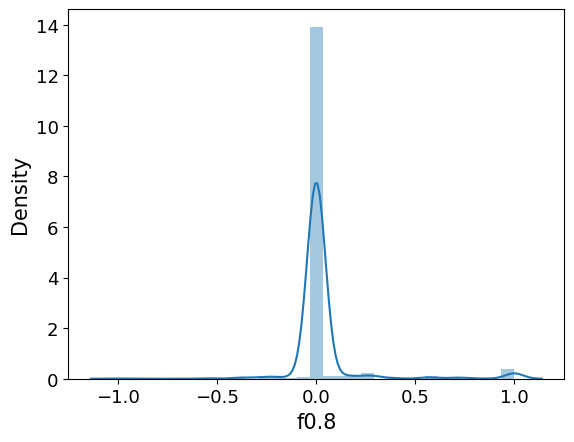

In [21]:
sns.distplot(points_COMB[metric] - points_NWP[metric]);